In [1]:
from pathlib import Path
import numpy as np
from PIL import Image

BASE_DIR = Path.cwd().parent

DATASET_DIR = (
    BASE_DIR
    / "dataset"
    / "Indian_Spice_Dataset"
)

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

IMG_SIZE = (64, 64)

print("Current directory:", Path.cwd())
print("Dataset path:", DATASET_DIR)
print("Dataset exists:", DATASET_DIR.exists())

if DATASET_DIR.exists():
    classes = sorted([
        folder.name
        for folder in DATASET_DIR.iterdir()
        if folder.is_dir()
    ])
    print("Classes:", classes)
else:
    print("ERROR: Dataset folder not found!")

Current directory: c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification\notebooks
Dataset path: c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification\dataset\Indian_Spice_Dataset
Dataset exists: True
Classes: ['Bay Leaf', 'Caraway seeds', 'Cloves', 'Mace', 'Stone Flowers']


In [2]:
from pathlib import Path

# Project root = one level above the notebooks folder
BASE_DIR = Path.cwd().parent

# Dataset location
DATASET_DIR = BASE_DIR / "dataset" / "Indian Spices Image Dataset"

print("Dataset path:")
print(DATASET_DIR)

print("\nDataset exists:", DATASET_DIR.exists())

Dataset path:
c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification\dataset\Indian Spices Image Dataset

Dataset exists: False


In [3]:
# ============================================================
# LOAD IMAGES
# ============================================================

X = []
y = []

for class_name in classes:

    class_dir = DATASET_DIR / class_name

    image_files = [
        file
        for file in class_dir.rglob("*")
        if (
            file.is_file()
            and file.suffix.lower() in IMAGE_EXTENSIONS
        )
    ]

    print(
        f"Loading {class_name}: "
        f"{len(image_files)} images"
    )

    for image_path in image_files:

        try:

            image = Image.open(
                image_path
            ).convert("RGB")

            image = image.resize(
                IMG_SIZE
            )

            image_array = np.array(
                image,
                dtype=np.float32
            )

            image_array = (
                image_array / 255.0
            )

            X.append(image_array)
            y.append(class_name)

        except Exception as e:

            print(
                f"Skipped {image_path.name}: {e}"
            )

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(y)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Loading Bay Leaf: 0 images
Loading Caraway seeds: 0 images
Loading Cloves: 0 images
Loading Mace: 0 images
Loading Stone Flowers: 0 images

X shape: (0,)
y shape: (0,)


In [4]:
# Count images in each class

from pathlib import Path

# Correct dataset path
BASE_DIR = Path.cwd().parent
DATASET_DIR = BASE_DIR / "dataset" / "Indian_Spice_Dataset"

# Supported image extensions
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Check dataset
print("Dataset path:", DATASET_DIR)
print("Dataset exists:", DATASET_DIR.exists())

if not DATASET_DIR.exists():
    raise FileNotFoundError(f"Dataset not found: {DATASET_DIR}")

# Get class folders
classes = sorted([
    folder.name
    for folder in DATASET_DIR.iterdir()
    if folder.is_dir()
])

# Count images
class_counts = {}

for class_name in classes:
    class_dir = DATASET_DIR / class_name

    count = sum(
        1
        for file in class_dir.iterdir()
        if file.is_file()
        and file.suffix.lower() in image_extensions
    )

    class_counts[class_name] = count

print("\nImage count per class:\n")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Dataset path: c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification\dataset\Indian_Spice_Dataset
Dataset exists: True

Image count per class:

Bay Leaf: 1085
Caraway seeds: 1110
Cloves: 827
Mace: 854
Stone Flowers: 877


In [5]:
# ============================================================
# LABEL ENCODING
# ============================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Class mapping:")

for index, class_name in enumerate(
    label_encoder.classes_
):
    print(
        f"{index} → {class_name}"
    )

print("\nEncoded shape:", y_encoded.shape)

Class mapping:

Encoded shape: (0,)


In [6]:
# Check image properties

sample_path = None

for class_name in classes:
    class_dir = DATASET_DIR / class_name

    image_files = [
        file for file in class_dir.iterdir()
        if file.is_file() and file.suffix.lower() in image_extensions
    ]

    if image_files:
        sample_path = image_files[0]
        break

image = Image.open(sample_path)

print("Sample image:", sample_path.name)
print("Image size:", image.size)
print("Image mode:", image.mode)

Sample image: BayLeaf1.jpg
Image size: (1440, 1080)
Image mode: RGB


In [7]:
# ============================================================
# LOAD AND PREPROCESS ALL IMAGES
# ============================================================

# Image size for the ANN
IMG_SIZE = (64, 64)

# Supported image formats
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

# Empty lists for images and labels
X = []
y = []

print("Starting image loading...\n")


# ============================================================
# LOOP THROUGH EACH SPICE CLASS
# ============================================================

for class_name in classes:

    class_dir = DATASET_DIR / class_name

    # Find all image files
    image_files = [
        file
        for file in class_dir.rglob("*")
        if (
            file.is_file()
            and file.suffix.lower() in IMAGE_EXTENSIONS
        )
    ]

    print(
        f"Loading {class_name}: "
        f"{len(image_files)} images"
    )


    # ========================================================
    # LOAD EACH IMAGE
    # ========================================================

    for image_path in image_files:

        try:

            # Open image and convert to RGB
            image = Image.open(
                image_path
            ).convert("RGB")

            # Resize image
            image = image.resize(
                IMG_SIZE
            )

            # Convert image to NumPy array
            image_array = np.array(
                image,
                dtype=np.float32
            )

            # Normalize pixel values
            # 0-255 → 0-1
            image_array = (
                image_array / 255.0
            )

            # Store image
            X.append(
                image_array
            )

            # Store corresponding class
            y.append(
                class_name
            )

        except Exception as e:

            print(
                f"Skipped: {image_path.name} "
                f"| Error: {e}"
            )


# ============================================================
# CONVERT LISTS TO NUMPY ARRAYS
# ============================================================

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 50)

print("IMAGE LOADING COMPLETED")

print("=" * 50)

print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

print(
    "Image size:",
    IMG_SIZE
)

print(
    "Number of images:",
    len(X)
)

print(
    "Number of labels:",
    len(y)
)

Starting image loading...

Loading Bay Leaf: 1085 images
Loading Caraway seeds: 1110 images
Loading Cloves: 827 images
Loading Mace: 854 images
Loading Stone Flowers: 877 images

IMAGE LOADING COMPLETED
X shape: (4753, 64, 64, 3)
y shape: (4753,)
Image size: (64, 64)
Number of images: 4753
Number of labels: 4753


In [8]:
# ============================================================
# ENCODE SPICE LABELS
# ============================================================

from sklearn.preprocessing import LabelEncoder

# Create label encoder
label_encoder = LabelEncoder()

# Convert spice names into numbers
y_encoded = label_encoder.fit_transform(y)

print("Class mapping:")
print("=" * 40)

for index, class_name in enumerate(label_encoder.classes_):
    print(f"{index} → {class_name}")

print("\nEncoded labels shape:", y_encoded.shape)
print("Unique encoded labels:", np.unique(y_encoded))

Class mapping:
0 → Bay Leaf
1 → Caraway seeds
2 → Cloves
3 → Mace
4 → Stone Flowers

Encoded labels shape: (4753,)
Unique encoded labels: [0 1 2 3 4]


In [9]:
# ============================================================
# FLATTEN IMAGES
# ============================================================

# ANN requires 2D input:
# (number of samples, number of features)

X_flat = X.reshape(
    X.shape[0],
    -1
)

print("Original X shape:")
print(X.shape)

print("\nFlattened X shape:")
print(X_flat.shape)


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_flat,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("\nTraining data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Original X shape:
(4753, 64, 64, 3)

Flattened X shape:
(4753, 12288)

Training data:
X_train: (3802, 12288)
y_train: (3802,)

Testing data:
X_test: (951, 12288)
y_test: (951,)


In [10]:
# ============================================================
# STANDARD SCALER
# ============================================================

from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same fitted scaler
X_test_scaled = scaler.transform(X_test)

print("Original training shape:")
print(X_train.shape)

print("\nScaled training shape:")
print(X_train_scaled.shape)

print("\nOriginal testing shape:")
print(X_test.shape)

print("\nScaled testing shape:")
print(X_test_scaled.shape)

Original training shape:
(3802, 12288)

Scaled training shape:
(3802, 12288)

Original testing shape:
(951, 12288)

Scaled testing shape:
(951, 12288)


In [11]:
# ============================================================
# BUILD ANN MODEL
# ============================================================

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


# Number of input features
input_features = X_train_scaled.shape[1]

# Number of spice classes
num_classes = len(label_encoder.classes_)

print("Input features:", input_features)
print("Number of classes:", num_classes)


# ============================================================
# CREATE MODEL
# ============================================================

model = Sequential([

    Dense(
        256,
        activation="relu",
        input_shape=(input_features,)
    ),

    Dropout(0.30),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.30),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        num_classes,
        activation="softmax"
    )
])


# ============================================================
# MODEL SUMMARY
# ============================================================

model.summary()

Input features: 12288
Number of classes: 5


c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,187,461 (12.16 MB)

 Trainable params: 3,187,461 (12.16 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
import sys
import numpy as np

print("Python:", sys.version)
print("NumPy:", np.__version__)

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
NumPy: 2.4.6


In [13]:
import sys
import numpy as np

print("Python executable:")
print(sys.executable)

print("\nNumPy version:")
print(np.__version__)

Python executable:
c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification\.venv\Scripts\python.exe

NumPy version:
2.4.6


In [14]:
import sys
import numpy as np

print("Python executable:")
print(sys.executable)

print("\nNumPy version:")
print(np.__version__)

Python executable:
c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification\.venv\Scripts\python.exe

NumPy version:
2.4.6


In [15]:
import sys
import numpy as np

print("Python executable:")
print(sys.executable)

print("\nNumPy version:")
print(np.__version__)

Python executable:
c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification\.venv\Scripts\python.exe

NumPy version:
2.4.6


In [16]:
import sys
import numpy as np

print("Python executable:")
print(sys.executable)

print("\nNumPy version:")
print(np.__version__)

Python executable:
c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification\.venv\Scripts\python.exe

NumPy version:
2.4.6


In [17]:
import sys
import numpy as np

print("Python executable:")
print(sys.executable)

print("\nNumPy version:")
print(np.__version__)

Python executable:
c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification\.venv\Scripts\python.exe

NumPy version:
2.4.6


In [18]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [19]:
import sys
import numpy as np

print(sys.executable)
print(np.__version__)

c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification\.venv\Scripts\python.exe
2.4.6


In [20]:
import sys
import numpy as np

print("Python executable:")
print(sys.executable)

print("\nNumPy:")
print(np.__version__)

Python executable:
c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification\.venv\Scripts\python.exe

NumPy:
2.4.6


In [21]:
# ============================================================
# TEST TENSORFLOW
# ============================================================

import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [22]:
# ============================================================
# BUILD ANN MODEL
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Number of input features
input_features = X_train_scaled.shape[1]

# Number of spice classes
num_classes = len(label_encoder.classes_)

print("Input features:", input_features)
print("Number of classes:", num_classes)

# Create ANN
model = Sequential([

    Dense(
        256,
        activation="relu",
        input_shape=(input_features,)
    ),

    Dropout(0.30),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.30),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        num_classes,
        activation="softmax"
    )
])

# Display model architecture
model.summary()

Input features: 12288
Number of classes: 5


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,187,461 (12.16 MB)

 Trainable params: 3,187,461 (12.16 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# ============================================================
# COMPILE ANN MODEL
# ============================================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [25]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)


CLASSIFICATION REPORT


NameError: name 'y_pred' is not defined

In [26]:
# ============================================================
# MAKE PREDICTIONS ON TEST DATA
# ============================================================

y_probability = model.predict(
    X_test_scaled,
    verbose=0
)

y_pred = np.argmax(
    y_probability,
    axis=1
)

print("Predictions created successfully.")
print("Number of predictions:", len(y_pred))

Predictions created successfully.
Number of predictions: 951


In [27]:
# ============================================================
# CREATE TEST PREDICTIONS
# ============================================================

import numpy as np

y_probability = model.predict(
    X_test_scaled,
    verbose=0
)

y_pred = np.argmax(
    y_probability,
    axis=1
)

print("y_pred created successfully.")
print("Number of predictions:", len(y_pred))

y_pred created successfully.
Number of predictions: 951


In [ ]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import joblib


# ============================================================
# ENVIRONMENT
# ============================================================

print("=" * 60)
print("ENVIRONMENT")
print("=" * 60)

print("Python:", sys.executable)
print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)


# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path.cwd().parent

DATASET_DIR = (
    BASE_DIR
    / "dataset"
    / "Indian_Spice_Dataset"
)

MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)


print("\nBase directory:", BASE_DIR)
print("Dataset directory:", DATASET_DIR)
print("Dataset exists:", DATASET_DIR.exists())


if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATASET_DIR}"
    )


# ============================================================
# SETTINGS
# ============================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

IMG_SIZE = (64, 64)


# ============================================================
# FIND CLASSES
# ============================================================

classes = sorted([
    p.name
    for p in DATASET_DIR.iterdir()
    if p.is_dir()
])

print("\nClasses:", classes)
print("Number of classes:", len(classes))


if len(classes) == 0:
    raise ValueError(
        f"No class folders found inside: {DATASET_DIR}"
    )


# ============================================================
# LOAD IMAGES
# ============================================================

X = []
y = []

skipped = 0

print("\n" + "=" * 60)
print("LOADING IMAGES")
print("=" * 60)


for class_name in classes:

    class_dir = DATASET_DIR / class_name

    image_files = [
        p
        for p in class_dir.rglob("*")
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    print(
        f"Loading {class_name}: "
        f"{len(image_files)} images"
    )

    for image_path in image_files:

        try:

            image = Image.open(
                image_path
            ).convert("RGB")

            image = image.resize(IMG_SIZE)

            arr = (
                np.asarray(
                    image,
                    dtype=np.float32
                ) / 255.0
            )

            X.append(arr)
            y.append(class_name)

        except Exception as e:

            skipped += 1

            print(
                f"Skipped {image_path.name}: {e}"
            )


# ============================================================
# CONVERT TO NUMPY
# ============================================================

X = np.asarray(
    X,
    dtype=np.float32
)

y = np.asarray(y)


print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("Skipped:", skipped)


if len(X) == 0:
    raise ValueError(
        "No images were loaded."
    )


# ============================================================
# LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)


print("\nLabel mapping:")

for i, name in enumerate(
    label_encoder.classes_
):

    print(
        f"{i} -> {name}"
    )


# ============================================================
# FLATTEN IMAGES
# ============================================================

X_flat = X.reshape(
    X.shape[0],
    -1
)

print(
    "\nFlattened shape:",
    X_flat.shape
)


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_flat,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)


print(
    "X_train:",
    X_train.shape
)

print(
    "X_test:",
    X_test.shape
)


# ============================================================
# STANDARD SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)


print(
    "X_train_scaled:",
    X_train_scaled.shape
)

print(
    "X_test_scaled:",
    X_test_scaled.shape
)


# ============================================================
# MODEL SETTINGS
# ============================================================

input_features = X_train_scaled.shape[1]

num_classes = len(
    label_encoder.classes_
)


# ============================================================
# BUILD ANN MODEL
# ============================================================

model = Sequential([

    Dense(
        256,
        activation="relu",
        input_shape=(input_features,)
    ),

    Dropout(0.30),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.30),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        num_classes,
        activation="softmax"
    )
])


# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)


model.summary()


# ============================================================
# EARLY STOPPING
# ============================================================

early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True
)


# ============================================================
# TRAINING
# ============================================================

print("\n" + "=" * 60)
print("TRAINING")
print("=" * 60)


history = model.fit(

    X_train_scaled,

    y_train,

    validation_split=0.20,

    epochs=30,

    batch_size=32,

    callbacks=[early_stopping],

    verbose=1
)


# ============================================================
# TRAINING GRAPH
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# TEST RESULTS
# ============================================================

test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)


print("\n" + "=" * 60)
print("TEST RESULTS")
print("=" * 60)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Test Loss: "
    f"{test_loss:.4f}"
)


# ============================================================
# PREDICTIONS
# ============================================================

y_probability = model.predict(
    X_test_scaled,
    verbose=0
)

y_pred = np.argmax(
    y_probability,
    axis=1
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)


print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)


fig, ax = plt.subplots(
    figsize=(8, 8)
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title(
    "Spice Classification Confusion Matrix"
)

plt.tight_layout()

plt.show()


# ============================================================
# SAVE FILE PATHS
# ============================================================

MODEL_PATH = (
    MODEL_DIR
    / "spice_model.keras"
)

SCALER_PATH = (
    MODEL_DIR
    / "scaler.pkl"
)

ENCODER_PATH = (
    MODEL_DIR
    / "label_encoder.pkl"
)


# ============================================================
# SAVE MODEL + SCALER + ENCODER
# ============================================================

model.save(
    MODEL_PATH
)

joblib.dump(
    scaler,
    SCALER_PATH
)

joblib.dump(
    label_encoder,
    ENCODER_PATH
)


# ============================================================
# FINAL OUTPUT
# ============================================================

print("\n" + "=" * 60)
print("PROJECT COMPLETED")
print("=" * 60)

print(
    "Model:",
    MODEL_PATH
)

print(
    "Scaler:",
    SCALER_PATH
)

print(
    "Encoder:",
    ENCODER_PATH
)

print(
    f"Final Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)
# ============================================================
# TEST A NEW BAY LEAF IMAGE
# ============================================================

# Test image path
image_path = BASE_DIR / "test_images" / "bayleaf_test.jpg"

print("Image path:")
print(image_path)

print("\nImage exists:", image_path.exists())


# ============================================================
# CHECK IMAGE
# ============================================================

if not image_path.exists():
    raise FileNotFoundError(
        f"""
Test image not found.

Expected location:
{image_path}

Please check that:
1. The folder is named 'test_images'
2. The image is named 'bayleaf_test.jpg'
3. The image is inside the test_images folder
"""
    )


# ============================================================
# LOAD IMAGE
# ============================================================

image = Image.open(
    image_path
).convert("RGB")


# ============================================================
# DISPLAY IMAGE
# ============================================================

plt.figure(figsize=(5, 5))

plt.imshow(image)

plt.axis("off")

plt.title("Test Bay Leaf Image")

plt.show()


# ============================================================
# RESIZE
# ============================================================

image = image.resize((64, 64))


# ============================================================
# CONVERT TO NUMPY
# ============================================================

image_array = np.asarray(
    image,
    dtype=np.float32
)


# ============================================================
# NORMALIZE
# ============================================================

image_array = image_array / 255.0


# ============================================================
# FLATTEN
# ============================================================

image_flat = image_array.reshape(
    1,
    -1
)

print(
    "Feature shape:",
    image_flat.shape
)


# ============================================================
# SCALE
# ============================================================

image_scaled = scaler.transform(
    image_flat
)


# ============================================================
# PREDICT
# ============================================================

probabilities = model.predict(
    image_scaled,
    verbose=0
)


# ============================================================
# FIND PREDICTION
# ============================================================

predicted_index = np.argmax(
    probabilities[0]
)

confidence = probabilities[0][
    predicted_index
]


# ============================================================
# DECODE CLASS
# ============================================================

predicted_class = (
    label_encoder.inverse_transform(
        [predicted_index]
    )[0]
)


# ============================================================
# DISPLAY RESULT
# ============================================================

print("\n" + "=" * 50)

print(
    "Predicted spice:",
    predicted_class
)

print(
    f"Confidence: "
    f"{confidence * 100:.2f}%"
)

print("=" * 50)


# ============================================================
# ALL CLASS PROBABILITIES
# ============================================================

print("\nAll probabilities:")

for class_name, probability in zip(
    label_encoder.classes_,
    probabilities[0]
):

    print(
        f"{class_name}: "
        f"{probability * 100:.2f}%"
    )

Image path:
c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification\test_images\bayleaf_test.jpg

Image exists: False


FileNotFoundError: 
Test image not found.

Expected location:
c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification\test_images\bayleaf_test.jpg

Please check that:
1. The folder is named 'test_images'
2. The image is named 'bayleaf_test.jpg'
3. The image is inside the test_images folder


Selected image:
C:/Users/sarag/OneDrive/Desktop/Indian_Spice_Classification_New/dataset/Indian Spices Image Dataset/Mace/Mace1.jpg


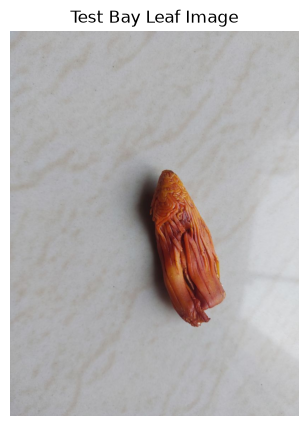


Predicted spice: Mace
Confidence: 100.00%

All probabilities:
Bay Leaf: 0.00%
Caraway seeds: 0.00%
Cloves: 0.00%
Mace: 100.00%
Stone Flowers: 0.00%


In [15]:
# ============================================================
# TEST A NEW IMAGE
# ============================================================

from tkinter import Tk, filedialog

# Open Windows file picker
root = Tk()
root.withdraw()

image_path = filedialog.askopenfilename(
    title="Select a Bay Leaf Image",
    filetypes=[
        ("Image files", "*.jpg *.jpeg *.png *.bmp *.webp")
    ]
)

root.destroy()


# ============================================================
# CHECK SELECTION
# ============================================================

if not image_path:

    print("❌ No image selected.")

else:

    print("Selected image:")
    print(image_path)


    # ========================================================
    # LOAD IMAGE
    # ========================================================

    image = Image.open(
        image_path
    ).convert("RGB")


    # ========================================================
    # DISPLAY IMAGE
    # ========================================================

    plt.figure(figsize=(5, 5))

    plt.imshow(image)

    plt.axis("off")

    plt.title("Test Bay Leaf Image")

    plt.show()


    # ========================================================
    # PREPROCESS
    # ========================================================

    image = image.resize(
        (64, 64)
    )

    image_array = np.array(
        image,
        dtype=np.float32
    )

    image_array = (
        image_array / 255.0
    )

    image_flat = image_array.reshape(
        1, -1
    )


    # ========================================================
    # SCALE
    # ========================================================

    image_scaled = scaler.transform(
        image_flat
    )


    # ========================================================
    # PREDICT
    # ========================================================

    probabilities = model.predict(
        image_scaled,
        verbose=0
    )


    predicted_index = np.argmax(
        probabilities[0]
    )

    confidence = probabilities[0][
        predicted_index
    ]


    predicted_class = (
        label_encoder.inverse_transform(
            [predicted_index]
        )[0]
    )


    # ========================================================
    # RESULT
    # ========================================================

    print("\n" + "=" * 50)

    print(
        "Predicted spice:",
        predicted_class
    )

    print(
        f"Confidence: "
        f"{confidence * 100:.2f}%"
    )

    print("=" * 50)


    # ========================================================
    # ALL PROBABILITIES
    # ========================================================

    print("\nAll probabilities:")

    for class_name, probability in zip(
        label_encoder.classes_,
        probabilities[0]
    ):

        print(
            f"{class_name}: "
            f"{probability * 100:.2f}%"
        )

In [34]:
# ============================================================
# TEST A BAY LEAF FROM THE TEST SET
# ============================================================

# Find the encoded number for Bay Leaf
bay_leaf_index = np.where(
    label_encoder.classes_ == "Bay Leaf"
)[0][0]

# Find Bay Leaf images in the test set
bay_leaf_positions = np.where(
    y_test == bay_leaf_index
)[0]

print("Bay Leaf test images:", len(bay_leaf_positions))

# Take the first Bay Leaf test image
test_position = bay_leaf_positions[0]

# Get prediction
probabilities = model.predict(
    X_test_scaled[test_position:test_position + 1],
    verbose=0
)

predicted_index = np.argmax(
    probabilities[0]
)

predicted_class = label_encoder.inverse_transform(
    [predicted_index]
)[0]

confidence = probabilities[0][predicted_index]

print("\nActual class:")
print("Bay Leaf")

print("\nPredicted class:")
print(predicted_class)

print(
    f"\nConfidence: {confidence * 100:.2f}%"
)

print("\nAll probabilities:")

for class_name, probability in zip(
    label_encoder.classes_,
    probabilities[0]
):
    print(
        f"{class_name}: {probability * 100:.2f}%"
    )

Bay Leaf test images: 217

Actual class:
Bay Leaf

Predicted class:
Bay Leaf

Confidence: 100.00%

All probabilities:
Bay Leaf: 100.00%
Caraway seeds: 0.00%
Cloves: 0.00%
Mace: 0.00%
Stone Flowers: 0.00%


In [32]:
# ============================================================
# DATA AUGMENTATION FOR ANN
# ============================================================

from PIL import ImageEnhance
import random

# Number of augmented copies per original training image
AUGMENT_COPIES = 1

X_augmented = []
y_augmented = []

print("Creating augmented training images...")

for image_array, label in zip(X_train, y_train):

    # --------------------------------------------------------
    # Original image is currently flattened.
    # Convert it back to 64x64x3
    # --------------------------------------------------------

    image_array = image_array.reshape(
        64,
        64,
        3
    )

    # Convert from 0-1 back to 0-255
    image_uint8 = (
        image_array * 255
    ).clip(
        0,
        255
    ).astype(
        np.uint8
    )

    image = Image.fromarray(
        image_uint8
    )

    # --------------------------------------------------------
    # Random horizontal flip
    # --------------------------------------------------------

    if random.random() < 0.5:

        image = image.transpose(
            Image.Transpose.FLIP_LEFT_RIGHT
        )

    # --------------------------------------------------------
    # Random brightness
    # --------------------------------------------------------

    brightness_factor = random.uniform(
        0.8,
        1.2
    )

    enhancer = ImageEnhance.Brightness(
        image
    )

    image = enhancer.enhance(
        brightness_factor
    )

    # --------------------------------------------------------
    # Convert back to NumPy
    # --------------------------------------------------------

    augmented_array = np.array(
        image,
        dtype=np.float32
    )

    # Normalize
    augmented_array = (
        augmented_array / 255.0
    )

    # Flatten
    augmented_flat = augmented_array.reshape(
        -1
    )

    X_augmented.append(
        augmented_flat
    )

    y_augmented.append(
        label
    )


# ============================================================
# CONVERT AUGMENTED DATA
# ============================================================

X_augmented = np.array(
    X_augmented,
    dtype=np.float32
)

y_augmented = np.array(
    y_augmented
)

print(
    "Augmented X shape:",
    X_augmented.shape
)

print(
    "Augmented y shape:",
    y_augmented.shape
)

Creating augmented training images...
Augmented X shape: (3802, 12288)
Augmented y shape: (3802,)


In [33]:
# ============================================================
# COMBINE ORIGINAL + AUGMENTED TRAINING DATA
# ============================================================

# Combine original training data with augmented data
X_train_combined = np.concatenate(
    [
        X_train,
        X_augmented
    ],
    axis=0
)

y_train_combined = np.concatenate(
    [
        y_train,
        y_augmented
    ],
    axis=0
)


print("Original training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nAugmented data:")
print("X_augmented:", X_augmented.shape)
print("y_augmented:", y_augmented.shape)

print("\nCombined training data:")
print("X_train_combined:", X_train_combined.shape)
print("y_train_combined:", y_train_combined.shape)

Original training data:
X_train: (3802, 12288)
y_train: (3802,)

Augmented data:
X_augmented: (3802, 12288)
y_augmented: (3802,)

Combined training data:
X_train_combined: (7604, 12288)
y_train_combined: (7604,)


In [34]:
# ============================================================
# SCALE COMBINED TRAINING DATA
# ============================================================

from sklearn.preprocessing import StandardScaler

# Create a NEW scaler for the augmented dataset
scaler_augmented = StandardScaler()

# Fit only on combined training data
X_train_combined_scaled = scaler_augmented.fit_transform(
    X_train_combined
)

# IMPORTANT:
# Test data remains completely untouched.
# Transform it using the new scaler.
X_test_scaled_augmented = scaler_augmented.transform(
    X_test
)

print("Combined training data:")
print(
    "X_train_combined_scaled:",
    X_train_combined_scaled.shape
)

print("\nTest data:")
print(
    "X_test_scaled_augmented:",
    X_test_scaled_augmented.shape
)

Combined training data:
X_train_combined_scaled: (7604, 12288)

Test data:
X_test_scaled_augmented: (951, 12288)


In [35]:
# ============================================================
# BUILD NEW ANN WITH AUGMENTED DATA
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

input_features = X_train_combined_scaled.shape[1]
num_classes = len(label_encoder.classes_)

print("Input features:", input_features)
print("Number of classes:", num_classes)

model_augmented = Sequential([
    
    Dense(
        256,
        activation="relu",
        input_shape=(input_features,)
    ),

    Dropout(0.30),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.30),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        num_classes,
        activation="softmax"
    )
])

# Compile
model_augmented.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n✅ New ANN compiled successfully.")

model_augmented.summary()

Input features: 12288
Number of classes: 5


c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



✅ New ANN compiled successfully.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,187,461 (12.16 MB)

 Trainable params: 3,187,461 (12.16 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# ============================================================
# TRAIN AUGMENTED ANN
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_augmented = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

print("=" * 60)
print("TRAINING AUGMENTED ANN")
print("=" * 60)

history_augmented = model_augmented.fit(
    X_train_combined_scaled,
    y_train_combined,

    validation_split=0.20,

    epochs=30,

    batch_size=32,

    callbacks=[
        early_stopping_augmented
    ],

    verbose=1
)

print("\n✅ Training completed.")

TRAINING AUGMENTED ANN
Epoch 1/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - accuracy: 0.5501 - loss: 1.9137 - val_accuracy: 0.6759 - val_loss: 0.8515
Epoch 2/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.6771 - loss: 0.9553 - val_accuracy: 0.8028 - val_loss: 0.5905
Epoch 3/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.8009 - loss: 0.5720 - val_accuracy: 0.8659 - val_loss: 0.4167
Epoch 4/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.8331 - loss: 0.4725 - val_accuracy: 0.8803 - val_loss: 0.3492
Epoch 5/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.8767 - loss: 0.3669 - val_accuracy: 0.9139 - val_loss: 0.2759
Epoch 6/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.8959 - loss: 0.3187 - val_accuracy: 0.9264 - val_loss: 0.2313
Epoch 7/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.9168 - loss: 0.2506 - val_accuracy: 0.9264 - val_loss: 0.2225
Epoch 8/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0

IMPROVED ANN - TEST EVALUATION
Test Loss: 0.1071
Test Accuracy: 96.74%

CLASSIFICATION REPORT
               precision    recall  f1-score   support

     Bay Leaf       0.99      1.00      0.99       217
Caraway seeds       0.96      1.00      0.98       222
       Cloves       0.92      0.92      0.92       165
         Mace       0.98      0.99      0.99       171
Stone Flowers       0.98      0.91      0.94       176

     accuracy                           0.97       951
    macro avg       0.97      0.96      0.96       951
 weighted avg       0.97      0.97      0.97       951


CONFUSION MATRIX
[[216   1   0   0   0]
 [  0 221   1   0   0]
 [  0   6 152   3   4]
 [  1   0   0 170   0]
 [  1   2  12   0 161]]


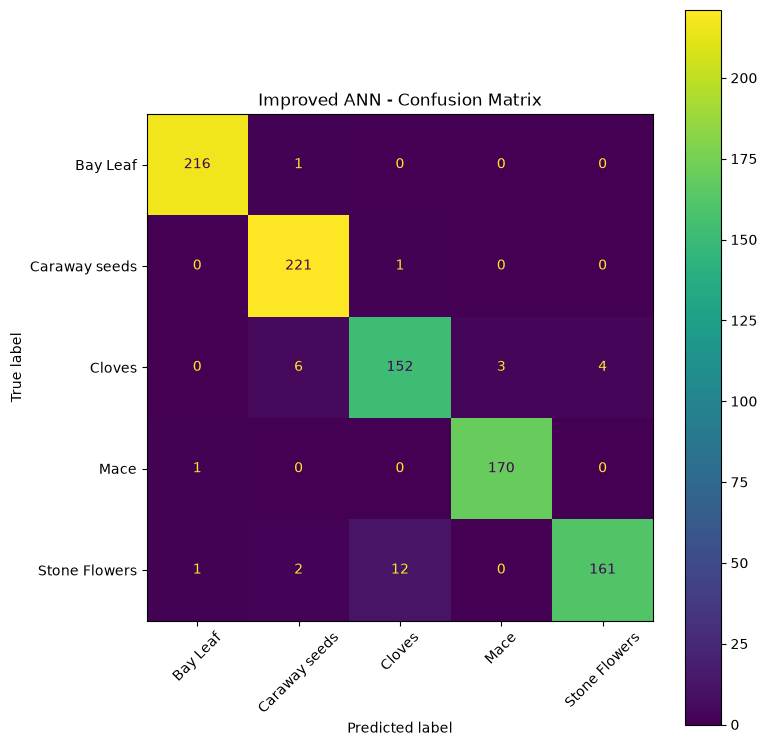

In [37]:
# ============================================================
# EVALUATE IMPROVED ANN
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("=" * 60)
print("IMPROVED ANN - TEST EVALUATION")
print("=" * 60)


# ============================================================
# TEST EVALUATION
# ============================================================

test_loss_aug, test_accuracy_aug = model_augmented.evaluate(
    X_test_scaled_augmented,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss_aug:.4f}")
print(f"Test Accuracy: {test_accuracy_aug * 100:.2f}%")


# ============================================================
# PREDICTIONS
# ============================================================

y_probability_aug = model_augmented.predict(
    X_test_scaled_augmented,
    verbose=0
)

y_pred_aug = np.argmax(
    y_probability_aug,
    axis=1
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_aug,
        target_names=label_encoder.classes_
    )
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

cm_aug = confusion_matrix(
    y_test,
    y_pred_aug
)

print(cm_aug)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_aug,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("Improved ANN - Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# TEST EXTERNAL IMAGE WITH IMPROVED ANN
# ============================================================

from tkinter import Tk, filedialog

# Open file picker
root = Tk()
root.withdraw()

image_path = filedialog.askopenfilename(
    title="Select a Bay Leaf Image",
    filetypes=[
        ("Image files", "*.jpg *.jpeg *.png *.bmp *.webp")
    ]
)

root.destroy()

if not image_path:
    print("No image selected.")

else:
    print("Selected:", image_path)

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Display
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title("External Test Image")
    plt.show()

    # Resize exactly like training
    image = image.resize((64, 64))

    # Convert to NumPy
    image_array = np.array(
        image,
        dtype=np.float32
    )

    # Normalize
    image_array = image_array / 255.0

    # Flatten
    image_flat = image_array.reshape(1, -1)

    # IMPORTANT: use the scaler from augmented training
    image_scaled = scaler_augmented.transform(
        image_flat
    )

    # Predict with improved model
    probabilities = model_augmented.predict(
        image_scaled,
        verbose=0
    )

    predicted_index = np.argmax(
        probabilities[0]
    )

    predicted_class = label_encoder.inverse_transform(
        [predicted_index]
    )[0]

    confidence = probabilities[0][predicted_index]

    print("\n" + "=" * 50)
    print("PREDICTION RESULT")
    print("=" * 50)

    print("Predicted spice:", predicted_class)
    print(f"Confidence: {confidence * 100:.2f}%")

    print("\nAll probabilities:")

    for class_name, probability in zip(
        label_encoder.classes_,
        probabilities[0]
    ):
        print(
            f"{class_name}: "
            f"{probability * 100:.2f}%"
        )

In [39]:
# ============================================================
# SAVE IMPROVED ANN MODEL
# ============================================================

import joblib
from pathlib import Path

MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "spice_model_augmented.keras"
SCALER_PATH = MODEL_DIR / "scaler_augmented.pkl"
ENCODER_PATH = MODEL_DIR / "label_encoder.pkl"

# ------------------------------------------------------------
# Save Keras model
# ------------------------------------------------------------

model_augmented.save(MODEL_PATH)

print("Keras model saved:")
print(MODEL_PATH)


# ------------------------------------------------------------
# Save H5 model
# ------------------------------------------------------------

H5_PATH = MODEL_DIR / "spice_model_augmented.h5"

model_augmented.save(H5_PATH)

print("H5 model saved:")
print(H5_PATH)


# ------------------------------------------------------------
# Save scaler
# ------------------------------------------------------------

joblib.dump(
    scaler_augmented,
    SCALER_PATH
)

print("Scaler saved:")
print(SCALER_PATH)


# ------------------------------------------------------------
# Save label encoder
# ------------------------------------------------------------

joblib.dump(
    label_encoder,
    ENCODER_PATH
)

print("Label encoder saved:")
print(ENCODER_PATH)


# ------------------------------------------------------------
# FINAL
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("ALL MODEL FILES SAVED SUCCESSFULLY")
print("=" * 60)

Keras model saved:
c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification\models\spice_model_augmented.keras
H5 model saved:
c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification\models\spice_model_augmented.h5
Scaler saved:
c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification\models\scaler_augmented.pkl
Label encoder saved:
c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification\models\label_encoder.pkl

ALL MODEL FILES SAVED SUCCESSFULLY
